In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path

LOAD DATA

In [6]:
base_path = Path('data_export_2026_03_01/data_export_2026_02_27')

# Then use / operator to build paths
business_lad = pd.read_parquet(base_path / 'business_counts/Business_counts_IS8_LADs.parquet', engine='fastparquet')
business_msoa = pd.read_parquet(base_path / 'business_counts/Business_counts_IS8_MSOAs.parquet', engine='fastparquet')


In [7]:
employee_lad = pd.read_parquet(base_path / 'employee_counts/Employee_counts_IS8_LADs.parquet', engine='fastparquet')
employee_msoa = pd.read_parquet(base_path / 'employee_counts/Employee_counts_IS8_MSOAs.parquet', engine='fastparquet')

EXPLORE BUSINESS DATA

In [8]:
print(f"business_lad shape is {business_lad.shape}")
print(f"business_msoa shape is {business_msoa.shape}")

# What are the actual columns?
print(business_msoa.columns.tolist())
print(business_lad.columns.tolist())

# Are there any nulls?
print(business_msoa.isnull().sum())
print(business_lad.isnull().sum())

# Data types
print(business_msoa.dtypes)
print(business_lad.dtypes)

# What does the geographic ID column look like?
print(business_msoa['GEOGRAPHY_CODE'].unique()[:10])
print(business_lad['GEOGRAPHY_CODE'].unique()[:10])

business_lad shape is (1249600, 9)
business_msoa shape is (6297280, 9)
['YEAR', 'SIZE_BAND', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE', 'IS8_SECTOR', 'FRONTIER_SECTOR', 'INDUSTRY_CODE', 'OBS_VALUE']
['YEAR', 'SIZE_BAND', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE', 'IS8_SECTOR', 'FRONTIER_SECTOR', 'INDUSTRY_CODE', 'OBS_VALUE']
YEAR                     0
SIZE_BAND                0
GEOGRAPHY_CODE           0
GEOGRAPHY_NAME           0
GEOGRAPHY_TYPE           0
IS8_SECTOR               0
FRONTIER_SECTOR    4150480
INDUSTRY_CODE            0
OBS_VALUE                0
dtype: int64
YEAR                    0
SIZE_BAND               0
GEOGRAPHY_CODE          0
GEOGRAPHY_NAME          0
GEOGRAPHY_TYPE          0
IS8_SECTOR              0
FRONTIER_SECTOR    823600
INDUSTRY_CODE           0
OBS_VALUE               0
dtype: int64
YEAR                int16
SIZE_BAND          object
GEOGRAPHY_CODE     object
GEOGRAPHY_NAME     object
GEOGRAPHY_TYPE     object
IS8_SECTOR        

In [14]:
business_msoa.head(10)


,YEAR,SIZE_BAND,GEOGRAPHY_CODE,GEOGRAPHY_NAME,GEOGRAPHY_TYPE,IS8_SECTOR,FRONTIER_SECTOR,INDUSTRY_CODE,OBS_VALUE
0,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Aerospace manufacturing,303,0
1,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Aerospace manufacturing,3316,0
2,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Agritech,283,0
3,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Automotive manufacturing,29,0
4,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Batteries,272,0
5,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,20,0
6,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,26,0
7,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,27,0
8,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,28,0
9,2016,large,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,30,0


In [9]:
business_msoa.groupby('IS8_SECTOR')['OBS_VALUE'].sum()
business_lad.groupby('GEOGRAPHY_NAME')['OBS_VALUE'].sum().sort_values(ascending = False)

business_lad[~business_lad['GEOGRAPHY_NAME'].isin(['Great Britain', 'England and Wales', 'England'])]\
    .groupby(['IS8_SECTOR', 'GEOGRAPHY_NAME'])['OBS_VALUE'].sum()\
    .reset_index()\
    .groupby('IS8_SECTOR')\
    .apply(lambda x: x.nlargest(3, 'OBS_VALUE'), include_groups=False)\
    .reset_index(level=0)

,IS8_SECTOR,GEOGRAPHY_NAME,OBS_VALUE
250,Advanced manufacturing,Scotland,18320
316,Advanced manufacturing,Wales,13285
19,Advanced manufacturing,Birmingham,4180
602,Creative Industries,Scotland,147590
687,Creative Industries,Westminster,119440
400,Creative Industries,Camden,93400
723,Defence sector,Birmingham,100
954,Defence sector,Scotland,85
1020,Defence sector,Wales,65
1306,Digital and Technology,Scotland,210340


In [10]:
employee_lad.groupby('IS8_SECTOR')['OBS_VALUE'].sum().sort_values(ascending = False)

IS8_SECTOR
Total                                 1178186445
Professional and Business Services     213274280
Digital and Technology                  83995605
Financial Services                      68252780
Creative Industries                     60601750
Advanced manufacturing                  32892680
Life Sciences                            3797270
Defence sector                            672285
Name: OBS_VALUE, dtype: Int64

CHECK GEOGRAPHIES REPRESENTED IN THE DATA - WE HAVE ENGLAND, SCOTLAND AND WALES

In [11]:
# Check all geography code prefixes in original business data
print(business_msoa['GEOGRAPHY_CODE'].str[0].value_counts())

GEOGRAPHY_CODE
E    4582336
S    1475584
W     239360
Name: count, dtype: int64


CHECK THAT ALL GEOGRAPHIES ARE IN DATA FOR EACH YEAR

In [12]:
business_msoa['YEAR'].value_counts().sort_index()
#business_lad['YEAR'].value_counts().sort_index()

# Check number of unique geographies per year
business_msoa.groupby('YEAR')['GEOGRAPHY_CODE'].nunique()

YEAR
2016    1780
2017    1780
2018    1780
2019    1780
2020    1780
2021    1780
2022    1780
2023    1780
2024    1780
2025    1807
Name: GEOGRAPHY_CODE, dtype: int64

DO THE SAME FOR EMPLOYEE DATA

In [13]:
print(f"employee_lad shape is {employee_lad.shape}")
print(f"employee_msoa shape is {employee_msoa.shape}")

# What are the actual columns?
print(employee_msoa.columns.tolist())
print(employee_lad.columns.tolist())

# Are there any nulls?
print(employee_msoa.isnull().sum())
print(employee_lad.isnull().sum())

# Data types
print(employee_msoa.dtypes)
print(employee_lad.dtypes)

# What does the geographic ID column look like?
print(employee_msoa['GEOGRAPHY_CODE'].unique()[:10])
print(employee_lad['GEOGRAPHY_CODE'].unique()[:10])

employee_lad shape is (312400, 8)
employee_msoa shape is (1576080, 8)
['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE', 'IS8_SECTOR', 'FRONTIER_SECTOR', 'INDUSTRY_CODE', 'OBS_VALUE']
['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE', 'IS8_SECTOR', 'FRONTIER_SECTOR', 'INDUSTRY_CODE', 'OBS_VALUE']
YEAR                     0
GEOGRAPHY_CODE           0
GEOGRAPHY_NAME           0
GEOGRAPHY_TYPE           0
IS8_SECTOR               0
FRONTIER_SECTOR    1038780
INDUSTRY_CODE            0
OBS_VALUE                0
dtype: int64
YEAR                    0
GEOGRAPHY_CODE          0
GEOGRAPHY_NAME          0
GEOGRAPHY_TYPE          0
IS8_SECTOR              0
FRONTIER_SECTOR    205900
INDUSTRY_CODE           0
OBS_VALUE               0
dtype: int64
YEAR                int16
GEOGRAPHY_CODE     object
GEOGRAPHY_NAME     object
GEOGRAPHY_TYPE     object
IS8_SECTOR         object
FRONTIER_SECTOR    object
INDUSTRY_CODE      object
OBS_VALUE           Int64
dtype: object
YEAR  

In [14]:
employee_msoa.head(45)

,YEAR,GEOGRAPHY_CODE,GEOGRAPHY_NAME,GEOGRAPHY_TYPE,IS8_SECTOR,FRONTIER_SECTOR,INDUSTRY_CODE,OBS_VALUE
0,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Aerospace manufacturing,303,0
1,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Aerospace manufacturing,3316,0
2,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Agritech,283,0
3,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Automotive manufacturing,29,0
4,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,Batteries,272,10
5,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,20,0
6,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,26,0
7,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,27,10
8,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,28,0
9,2015,E02000984,Bolton 001,2021 super output areas - middle layer,Advanced manufacturing,None,30,0


In [15]:
#employee_msoa['YEAR'].value_counts().sort_index()
employee_lad['YEAR'].value_counts().sort_index()

# Check number of unique geographies per year
employee_msoa.groupby('YEAR')['GEOGRAPHY_CODE'].nunique()

# Check employment by IS8 sector & geogrphy
employee_lad[~employee_lad['GEOGRAPHY_NAME'].isin(['Great Britain', 'England and Wales', 'England'])]\
    .groupby(['IS8_SECTOR', 'GEOGRAPHY_NAME'])['OBS_VALUE'].sum()\
    .reset_index()\
    .groupby('IS8_SECTOR')\
    .apply(lambda x: x.nlargest(3, 'OBS_VALUE'), include_groups=False)\
    .reset_index(level=0)

,IS8_SECTOR,GEOGRAPHY_NAME,OBS_VALUE
316,Advanced manufacturing,Wales,516295
250,Advanced manufacturing,Scotland,514245
81,Advanced manufacturing,Derby,276760
687,Creative Industries,Westminster,1205650
602,Creative Industries,Scotland,821200
400,Creative Industries,Camden,817375
1030,Defence sector,West Berkshire,62000
985,Defence sector,Stevenage,25000
1002,Defence sector,Telford and Wrekin,9250
1306,Digital and Technology,Scotland,1578345


In [16]:
employee_lad.groupby('IS8_SECTOR')['OBS_VALUE'].sum().sort_values(ascending = False)

IS8_SECTOR
Total                                 1178186445
Professional and Business Services     213274280
Digital and Technology                  83995605
Financial Services                      68252780
Creative Industries                     60601750
Advanced manufacturing                  32892680
Life Sciences                            3797270
Defence sector                            672285
Name: OBS_VALUE, dtype: Int64

BEGIN CLEANING

* Business data set has size bands column when employee information does not. We can aggregate business counts across size bands to rectify this. Also removed "total" rows. 
* Employee data is missing defence sector, digital and technology, and life sciences data. Filter to common sectors for now. 


In [17]:
# Aggregate business counts across size bands - MSOA
bus_agg_msoa = business_msoa.groupby(
    ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE',
     'IS8_SECTOR', 'FRONTIER_SECTOR', 'INDUSTRY_CODE']
)['OBS_VALUE'].sum().reset_index()

# Aggregate business counts across size bands - LAD
bus_agg_lad = business_lad.groupby(
    ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE',
     'IS8_SECTOR', 'FRONTIER_SECTOR', 'INDUSTRY_CODE']
)['OBS_VALUE'].sum().reset_index()

# Remove Total rows from all four
bus_agg_msoa = bus_agg_msoa[bus_agg_msoa['INDUSTRY_CODE'] != 'Total']
bus_agg_lad = bus_agg_lad[bus_agg_lad['INDUSTRY_CODE'] != 'Total']
employee_msoa = employee_msoa[employee_msoa['INDUSTRY_CODE'] != 'Total']
employee_lad = employee_lad[employee_lad['INDUSTRY_CODE'] != 'Total']

# TEMPORARY: Filtering to sectors present in both datasets
# TO UPDATE: Add 'Defence sector', 'Digital and Technology', 'Life Sciences' once updated business counts data is received
shared_sectors = ['Advanced manufacturing', 'Creative Industries', 
                  'Financial Services', 'Professional and Business Services']

# Then filter to shared sectors
bus_agg_msoa = bus_agg_msoa[bus_agg_msoa['IS8_SECTOR'].isin(shared_sectors)]
employee_msoa = employee_msoa[employee_msoa['IS8_SECTOR'].isin(shared_sectors)]
bus_agg_lad = bus_agg_lad[bus_agg_lad['IS8_SECTOR'].isin(shared_sectors)]
employee_lad = employee_lad[employee_lad['IS8_SECTOR'].isin(shared_sectors)]

BEFORE we merge business and employee data at the msoa and lad levels, we need to check that the columns that we'll be matching on have the same values. 

In [18]:
# Check for any geography codes in one dataset not in the other
set(bus_agg_msoa['GEOGRAPHY_CODE']).symmetric_difference(set(employee_msoa['GEOGRAPHY_CODE']))

# Same for IS8_SECTOR
set(bus_agg_msoa['IS8_SECTOR']).symmetric_difference(set(employee_msoa['IS8_SECTOR']))

# Same for INDUSTRY_CODE
set(bus_agg_msoa['INDUSTRY_CODE']).symmetric_difference(set(employee_msoa['INDUSTRY_CODE']))

{'20',
 '26',
 '27',
 '28',
 '30',
 '3212',
 '58',
 '59',
 '60',
 '6201',
 '6202',
 '64',
 '65',
 '69',
 '70',
 '71',
 '7111',
 '72',
 '73',
 '74',
 '741',
 '742',
 '743',
 '77',
 '78',
 '82',
 '9101',
 '9102'}

In [19]:
#Check where difference in Industry Code between bus_agg and employee_msoa is coming from
print(set(bus_agg_msoa['IS8_SECTOR']) - set(employee_msoa['IS8_SECTOR']))
print(set(employee_msoa['IS8_SECTOR']) - set(bus_agg_msoa['IS8_SECTOR']))
print(set(bus_agg_msoa['INDUSTRY_CODE']) - set(employee_msoa['INDUSTRY_CODE']))
print(set(employee_msoa['INDUSTRY_CODE']) - set(bus_agg_msoa['INDUSTRY_CODE']))

set()
set()
set()
{'60', '9101', '30', '58', '9102', '26', '6202', '78', '71', '742', '3212', '69', '72', '77', '64', '6201', '28', '73', '70', '7111', '20', '743', '65', '82', '741', '59', '27', '74'}


In [20]:
# What sectors do these orphan industry codes belong to in employee data?
employee_msoa[employee_msoa['INDUSTRY_CODE'].isin(
    set(employee_msoa['INDUSTRY_CODE']) - set(bus_agg_msoa['INDUSTRY_CODE'])
)][['IS8_SECTOR', 'INDUSTRY_CODE']].drop_duplicates().sort_values('IS8_SECTOR')

,IS8_SECTOR,INDUSTRY_CODE
5,Advanced manufacturing,20
6,Advanced manufacturing,26
7,Advanced manufacturing,27
8,Advanced manufacturing,28
9,Advanced manufacturing,30
30,Creative Industries,9102
29,Creative Industries,9101
28,Creative Industries,743
26,Creative Industries,741
25,Creative Industries,7111


In [21]:
# What industry codes does business counts have for Creative Industries?
print(bus_agg_msoa[bus_agg_msoa['IS8_SECTOR'] == 'Creative Industries']['INDUSTRY_CODE'].unique())

# What industry codes does employee counts have for Creative Industries?
print(employee_msoa[employee_msoa['IS8_SECTOR'] == 'Creative Industries']['INDUSTRY_CODE'].unique())


['7021' '731' '591' '602' '592' '8552' '90' '5821' '62011']
['7021' '731' '591' '602' '592' '8552' '90' '5821' '62011' '3212' '58'
 '59' '60' '6201' '6202' '7111' '741' '742' '743' '9101' '9102']


There is a discrepancy in industry codes. To avoid this skewing our data, we can aggregate at the sector level before merging - this will drop Industry Code before we create merged datasets. 

We need to do this for MSOA and LAD levels. 


In [22]:
# Aggregate both up to sector level first for MSOA
bus_sector_msoa = bus_agg_msoa.groupby(
    ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE',
     'IS8_SECTOR', 'FRONTIER_SECTOR']
)['OBS_VALUE'].sum().reset_index()

emp_sector_msoa = employee_msoa.groupby(
    ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE',
     'IS8_SECTOR', 'FRONTIER_SECTOR']
)['OBS_VALUE'].sum().reset_index()

# Then merge
merged_msoa = bus_sector_msoa.merge(
    emp_sector_msoa,
    on=['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE',
        'IS8_SECTOR', 'FRONTIER_SECTOR'],
    how='inner',
    suffixes=('_business', '_employee')
)

In [23]:
# Aggregate both up to sector level - LAD
bus_sector_lad = bus_agg_lad.groupby(
    ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE',
     'IS8_SECTOR', 'FRONTIER_SECTOR']
)['OBS_VALUE'].sum().reset_index()

emp_sector_lad = employee_lad.groupby(
    ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE',
     'IS8_SECTOR', 'FRONTIER_SECTOR']
)['OBS_VALUE'].sum().reset_index()

# Merge LAD
merged_lad = bus_sector_lad.merge(
    emp_sector_lad,
    on=['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE',
        'IS8_SECTOR', 'FRONTIER_SECTOR'],
    how='inner',
    suffixes=('_business', '_employee')
)

# Verify both merges
print(merged_msoa.shape)
print(merged_lad.shape)
print(merged_msoa.isnull().sum())
print(merged_lad.isnull().sum())

#
merged_msoa_ew = merged_msoa[merged_msoa['GEOGRAPHY_CODE'].str.startswith(('E', 'W'))]
merged_msoa_scot = merged_msoa[merged_msoa['GEOGRAPHY_CODE'].str.startswith('S')]

merged_lad_ew = merged_lad[~merged_lad['GEOGRAPHY_CODE'].str.startswith('S')]
merged_lad_scot = merged_lad[merged_lad['GEOGRAPHY_CODE'].str.startswith('S')]

(222502, 8)
(44730, 8)
YEAR                  0
GEOGRAPHY_CODE        0
GEOGRAPHY_NAME        0
GEOGRAPHY_TYPE        0
IS8_SECTOR            0
FRONTIER_SECTOR       0
OBS_VALUE_business    0
OBS_VALUE_employee    0
dtype: int64
YEAR                  0
GEOGRAPHY_CODE        0
GEOGRAPHY_NAME        0
GEOGRAPHY_TYPE        0
IS8_SECTOR            0
FRONTIER_SECTOR       0
OBS_VALUE_business    0
OBS_VALUE_employee    0
dtype: int64


In [24]:
# Look at a sample of MSOA geography codes
print(merged_msoa['GEOGRAPHY_CODE'].head(20).values)

['E02000984' 'E02000984' 'E02000984' 'E02000984' 'E02000984' 'E02000984'
 'E02000984' 'E02000984' 'E02000984' 'E02000984' 'E02000984' 'E02000984'
 'E02000984' 'E02000984' 'E02000985' 'E02000985' 'E02000985' 'E02000985'
 'E02000985' 'E02000985']


In [25]:
print(merged_lad['GEOGRAPHY_CODE'].head(20).values)

['E06000001' 'E06000001' 'E06000001' 'E06000001' 'E06000001' 'E06000001'
 'E06000001' 'E06000001' 'E06000001' 'E06000001' 'E06000001' 'E06000001'
 'E06000001' 'E06000001' 'E06000002' 'E06000002' 'E06000002' 'E06000002'
 'E06000002' 'E06000002']


SUMMARY STATS - FOR NOW

In [26]:
# Summary Statistics
# Overall distribution of employee and business counts
merged_lad[['OBS_VALUE_business', 'OBS_VALUE_employee']].describe()


,OBS_VALUE_business,OBS_VALUE_employee
count,44730.0,44730.0
mean,328.854907,2426.737648
std,4456.004198,24641.61274
min,0.0,0.0
25%,5.0,20.0
50%,25.0,135.0
75%,70.0,450.0
max,180540.0,588000.0


In [27]:
# By sector
merged_lad.groupby('IS8_SECTOR')[['OBS_VALUE_business', 'OBS_VALUE_employee']].describe()

OBS_VALUE_business              \
                                                count        mean   
IS8_SECTOR                                                          
Advanced manufacturing                        12780.0     17.4777   
Creative Industries                           12780.0  250.627543   
Financial Services                             9585.0  267.407929   
Professional and Business Services             9585.0  909.774648   

                                                                          \
                                            std  min   25%    50%    75%   
IS8_SECTOR                                                                 
Advanced manufacturing               190.704287  0.0   0.0    0.0    5.0   
Creative Industries                 2291.614898  0.0   5.0   25.0   60.0   
Financial Services                  2417.061655  0.0  15.0   35.0   70.0   
Professional and Business Services  8904.898563  0.0  45.0  110.0  250.0   

                                             OBS_VALUE_employee               \
                                         max              count         mean   
IS8_SECTOR                                                                     
Advanced manufacturing                3785.0            12780.0   731.637324   
Creative Industries                  39105.0            12780.0  1185.169405   
Financial Services                   41495.0             9585.0  4272.215962   
Professional and Business Services  180540.0             9585.0  4496.817423   

                                                                             \
                                             std  min    25%    50%     75%   
IS8_SECTOR                                                                    
Advanced manufacturing               8040.074857  0.0    0.0    5.0    75.0   
Creative Industries                  10569.20248  0.0   20.0   75.0   205.0   
Financial Services                  35642.399308  0.0  115.0  270.0   745.0   
Professional and Business Services  36259.819895  0.0  250.0  500.0  1000.0   

                                              
                                         max  
IS8_SECTOR                                    
Advanced manufacturing              166000.0  
Creative Industries                 180000.0  
Financial Services                  588000.0  
Professional and Business Services  521000.0

In [28]:
# National IS-8 employment by sector over time
merged_lad.groupby(['YEAR', 'IS8_SECTOR'])['OBS_VALUE_employee'].sum().unstack()

IS8_SECTOR,Advanced manufacturing,Creative Industries,Financial Services,Professional and Business Services
YEAR,,,,
2016,1098320,1526995,4463280,4446350
2017,1037535,1527065,4462645,4438635
2018,1101990,1549235,4330110,4640290
2019,1093555,1651630,4501455,4611770
2020,1105010,1516770,4491260,4707620
2021,1042800,1758900,4909180,4938060
2022,942870,1846225,4543525,5058005
2023,951980,1909430,4606405,5145565
2024,976265,1860215,4641330,5115700


In [29]:
# What share of total IS-8 employment is in top 10 LADs?
for sector in shared_sectors:
    sector_data = merged_lad[merged_lad['IS8_SECTOR'] == sector]\
        .groupby('GEOGRAPHY_NAME')['OBS_VALUE_employee'].sum()\
        .sort_values(ascending=False)
    top10_share = sector_data.head(10).sum() / sector_data.sum()
    print(f"{sector}: top 10 LADs account for {top10_share:.1%} of employment")

Advanced manufacturing: top 10 LADs account for 79.5% of employment
Creative Industries: top 10 LADs account for 82.6% of employment
Financial Services: top 10 LADs account for 84.6% of employment
Professional and Business Services: top 10 LADs account for 80.1% of employment


LOAD IN BOUNDARIES DATA

In [30]:
# Load boundaries
lad_boundaries = gpd.read_file(base_path /'boundaries/UK_Local_Authority_Districts_December_2023_Boundaries_UK_BGC_2537431731774104276.geojson')
msoa_boundaries = gpd.read_file(base_path /'boundaries/Middle_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V3_-4477917303172606123.geojson')
iz_boundaries = gpd.read_file(base_path /'boundaries/SG_IZ_2022.geojson')

# Check the column names for the geography code
print(lad_boundaries.columns.tolist())
print(msoa_boundaries.columns.tolist())
print(iz_boundaries.columns.tolist())
print(iz_boundaries.crs)

['FID', 'LAD23CD', 'LAD23NM', 'LAD23NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']
['FID', 'MSOA21CD', 'MSOA21NM', 'MSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'GlobalID', 'geometry']
['IZCode', 'IZName', 'TotPop2022', 'geometry']
EPSG:4326


MERGE WITH ECONOMIC DATA

In [31]:
# Rename geography code columns to match your economic data
lad_boundaries = lad_boundaries.rename(columns={'LAD23CD': 'GEOGRAPHY_CODE'})
msoa_boundaries = msoa_boundaries.rename(columns={'MSOA21CD': 'GEOGRAPHY_CODE'})
iz_boundaries = iz_boundaries.rename(columns={'IZCode': 'GEOGRAPHY_CODE', 'IZName': 'GEOGRAPHY_NAME'})

print(bus_agg_msoa['GEOGRAPHY_CODE'].str[0].value_counts())
print(employee_msoa['GEOGRAPHY_CODE'].str[0].value_counts())

# Join economic data to boundaries
gdf_lad = lad_boundaries.merge(merged_lad, on='GEOGRAPHY_CODE', how='left')
gdf_msoa = msoa_boundaries.merge(merged_msoa, on='GEOGRAPHY_CODE', how='left')

# England & Wales MSOA spatial join
gdf_msoa_ew = msoa_boundaries.merge(merged_msoa_ew, on='GEOGRAPHY_CODE', how='left')
gdf_lad_ew = msoa_boundaries.merge(merged_lad_ew, on='GEOGRAPHY_CODE', how='left')

# Scottish IZ spatial join
gdf_msoa_scot = iz_boundaries.merge(merged_msoa_scot, on='GEOGRAPHY_CODE', how='left')
gdf_lad_scot = iz_boundaries.merge(merged_lad_scot, on='GEOGRAPHY_CODE', how='left')

# Concatenate into single GB-wide MSOA/IZ dataset
gdf_msoa = pd.concat([gdf_msoa_ew, gdf_msoa_scot], ignore_index=True)
gdf_msoa = gpd.GeoDataFrame(gdf_msoa, geometry='geometry', crs='EPSG:27700')

gdf_lad = pd.concat([gdf_lad_ew, gdf_lad_scot], ignore_index=True)
gdf_lad = gpd.GeoDataFrame(gdf_lad, geometry='geometry', crs='EPSG:27700')

# Verify
print(gdf_lad.shape)
print(gdf_msoa.shape)
print(type(gdf_lad))  # should still be GeoDataFrame

GEOGRAPHY_CODE
E    390540
S    125760
W     20400
Name: count, dtype: int64
GEOGRAPHY_CODE
E    754928
S    244412
W     39440
Name: count, dtype: int64
(8598, 20)
(229320, 20)
<class 'geopandas.geodataframe.GeoDataFrame'>


EPSG:27700
EPSG:27700
0


<Axes: >

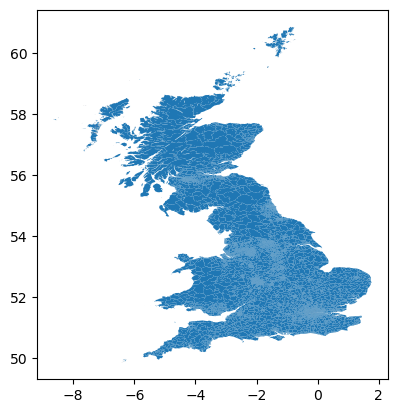

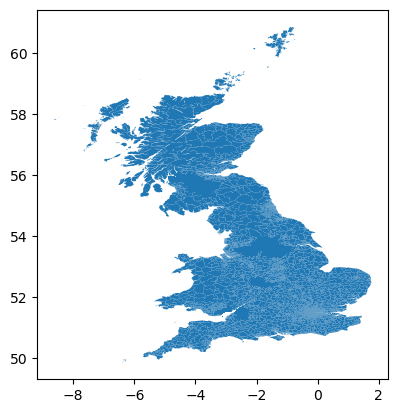

In [32]:
#Check alignment - CRS stands for Coordinate Reference System — it's the mathematical framework that defines how coordinates (numbers) map onto the actual surface of the Earth.
print(gdf_lad.crs)
print(gdf_msoa.crs)

# How many English LADs have economic data attached?
print(gdf_lad['OBS_VALUE_business'].notna().sum())

# Quick visual check
gdf_lad.plot()
gdf_msoa.plot()

In [33]:
#Then reproject to British National Grid ready for spatial analysis. 
#If you plan to do any distance-based spatial operations — like calculating distances between areas, computing area sizes, or running spatial weights matrices for Moran's I — you'll want to reproject to EPSG:27700 (British National Grid) at that point since calculations in degrees are geometrically distorted.
gdf_msoa = gdf_msoa.to_crs(epsg=27700)
gdf_lad = gdf_msoa.to_crs(epsg=27700)
iz_boundaries = iz_boundaries.to_crs(epsg=27700)

USE WEST AUTHORITY CODE IN LOOKUP TO FILTER MERGED DATA INTO A REGIONAL DATASET

In [34]:
# Load the lookup and check name of west authority
msoa_to_ca = pd.read_csv(base_path /'boundaries/MSOA_to_English_combined_authorities.csv')
print(msoa_to_ca.columns.tolist())
print(msoa_to_ca.head())
print(msoa_to_ca['CAUTH23NM'].unique())

# Extract WECA MSOA codes
weca_msoa_codes = msoa_to_ca[msoa_to_ca['CAUTH23NM'] == 'West of England']['MSOA21CD'].tolist()

# Extract WECA LAD codes
weca_lad_codes = msoa_to_ca[msoa_to_ca['CAUTH23NM'] == 'West of England']['LAD23CD'].unique().tolist()

# Filter your spatial datasets
gdf_weca_msoa = gdf_msoa[gdf_msoa['GEOGRAPHY_CODE'].isin(weca_msoa_codes)]
gdf_weca_lad = gdf_lad[gdf_lad['GEOGRAPHY_CODE'].isin(weca_lad_codes)]

# Verify - should be Bristol, Bath & NES, South Gloucestershire
print(gdf_weca_lad['GEOGRAPHY_NAME'].unique())

['MSOA21CD', 'MSOA21NM', 'LAD23CD', 'LAD23NM', 'CAUTH23CD', 'CAUTH23NM']
    MSOA21CD        MSOA21NM    LAD23CD     LAD23NM  CAUTH23CD    CAUTH23NM
0  E02002483  Hartlepool 001  E06000001  Hartlepool  E47000006  Tees Valley
1  E02002484  Hartlepool 002  E06000001  Hartlepool  E47000006  Tees Valley
2  E02002485  Hartlepool 003  E06000001  Hartlepool  E47000006  Tees Valley
3  E02002489  Hartlepool 007  E06000001  Hartlepool  E47000006  Tees Valley
4  E02002490  Hartlepool 008  E06000001  Hartlepool  E47000006  Tees Valley
['Tees Valley' 'Liverpool City Region' 'West of England'
 'Cambridgeshire and Peterborough' 'North East' 'North of Tyne'
 'Greater Manchester' 'South Yorkshire' 'West Midlands' 'West Yorkshire']
[]


BEGIN BUILDING LOCATION QUOTIENTS
* IS8 LQ - for LAD + MSOA
* Frontier Sector LQ – for LAD + MSOA

In [35]:
#Calculate total employment across all IS-8 sectors per area per year

# Total employees per area per year (across all IS-8 sectors)
total_emp_area = gdf_msoa.groupby(['GEOGRAPHY_CODE', 'YEAR'])['OBS_VALUE_employee'].sum().reset_index()
total_emp_area = total_emp_area.rename(columns={'OBS_VALUE_employee': 'total_emp_area'})

# Total employees nationally per year (across all IS-8 sectors)
total_emp_national = gdf_msoa.groupby('YEAR')['OBS_VALUE_employee'].sum().reset_index()
total_emp_national = total_emp_national.rename(columns={'OBS_VALUE_employee': 'total_emp_national'})

In [36]:
#Calculate national employment per IS-8 sector per year
# national totals now include England, Wales, and Scotland (IZs)
# This gives a GB-wide benchmark for LQ calculations

national_sector_emp = gdf_msoa.groupby(['YEAR', 'IS8_SECTOR'])['OBS_VALUE_employee'].sum().reset_index()
national_sector_emp = national_sector_emp.rename(columns={'OBS_VALUE_employee': 'national_sector_emp'})


In [37]:
#Merge totals back and calculate LOCATION QUOTIENT FOR MSOA

# Start with your main dataset
lq_msoa = gdf_msoa.copy()

# Merge in totals
lq_msoa = lq_msoa.merge(total_emp_area, on=['GEOGRAPHY_CODE', 'YEAR'])
lq_msoa = lq_msoa.merge(total_emp_national, on='YEAR')
lq_msoa = lq_msoa.merge(national_sector_emp, on=['YEAR', 'IS8_SECTOR'])

#convert Float64 to float64
lq_msoa['OBS_VALUE_employee'] = lq_msoa['OBS_VALUE_employee'].astype(float)
lq_msoa['OBS_VALUE_business'] = lq_msoa['OBS_VALUE_business'].astype(float)

# Calculate LQ
lq_msoa['LQ_employee'] = (
    (lq_msoa['OBS_VALUE_employee'] / lq_msoa['total_emp_area']) /
    (lq_msoa['national_sector_emp'] / lq_msoa['total_emp_national'])
)
lq_msoa['LQ_employee'] = lq_msoa['LQ_employee'].astype(float)

# Rename to make interpretation clear
# NOTE: LQ_IS8_relative measures sector concentration relative to the IS-8 
# economy only, not the whole economy. This is a placeholder until total 
# BRES employment data is available. Recalculate using whole-economy 
# denominator when data is received.
lq_msoa = lq_msoa.rename(columns={'LQ_employee': 'LQ_IS8_relative'})


In [38]:
#CALCULATING LQ FOR frontier sectors, only calculate where FRONTIER_SECTOR is not null:

# Filter to frontier sector rows only
frontier_msoa = lq_msoa[lq_msoa['FRONTIER_SECTOR'].notna()].copy()

# National employment per frontier sector per year
national_frontier_emp = frontier_msoa.groupby(['YEAR', 'FRONTIER_SECTOR'])['OBS_VALUE_employee'].sum().reset_index()
national_frontier_emp = national_frontier_emp.rename(columns={'OBS_VALUE_employee': 'national_frontier_emp'})

# Total employment per area per year (same denominator as before)
frontier_msoa = frontier_msoa.merge(national_frontier_emp, on=['YEAR', 'FRONTIER_SECTOR'])

# Calculate frontier LQ
frontier_msoa['LQ_frontier'] = (
    (frontier_msoa['OBS_VALUE_employee'] / frontier_msoa['total_emp_area']) /
    (frontier_msoa['national_frontier_emp'] / frontier_msoa['total_emp_national'])
)

In [39]:
# National average LQ should be ~1 for each sector/year
lq_msoa.groupby(['YEAR', 'IS8_SECTOR'])['LQ_IS8_relative'].mean().round(2)

# Check for infinities or NaNs from zero division
print(lq_msoa['LQ_IS8_relative'].isna().sum())
print((lq_msoa['LQ_IS8_relative'] == float('inf')).sum())

lq_msoa.groupby(['YEAR', 'IS8_SECTOR'])['LQ_IS8_relative'].mean().round(2)

21938
0


YEAR    IS8_SECTOR                        
2016.0  Advanced manufacturing                0.17
        Creative Industries                   0.23
        Financial Services                    0.18
        Professional and Business Services    0.54
2017.0  Advanced manufacturing                0.18
        Creative Industries                   0.24
        Financial Services                    0.17
        Professional and Business Services    0.53
2018.0  Advanced manufacturing                0.19
        Creative Industries                   0.23
        Financial Services                    0.18
        Professional and Business Services    0.51
2019.0  Advanced manufacturing                0.19
        Creative Industries                   0.23
        Financial Services                    0.18
        Professional and Business Services    0.52
2020.0  Advanced manufacturing                0.20
        Creative Industries                   0.21
        Financial Services             

In [40]:
## CALCULATING LOCATION QUOTIENT FOR LAD

# Step 1 — Total employees per LAD per year
total_emp_area_lad = gdf_lad.groupby(['GEOGRAPHY_CODE', 'YEAR'])['OBS_VALUE_employee'].sum().reset_index()
total_emp_area_lad = total_emp_area_lad.rename(columns={'OBS_VALUE_employee': 'total_emp_area'})

# Step 2 — Total employees nationally per year
total_emp_national_lad = gdf_lad.groupby('YEAR')['OBS_VALUE_employee'].sum().reset_index()
total_emp_national_lad = total_emp_national_lad.rename(columns={'OBS_VALUE_employee': 'total_emp_national'})

# Step 3 — National employment per IS-8 sector per year
national_sector_emp_lad = gdf_lad.groupby(['YEAR', 'IS8_SECTOR'])['OBS_VALUE_employee'].sum().reset_index()
national_sector_emp_lad = national_sector_emp_lad.rename(columns={'OBS_VALUE_employee': 'national_sector_emp'})

# Step 4 — Merge totals and calculate LQ
lq_lad = gdf_lad.copy()
lq_lad = lq_lad.merge(total_emp_area_lad, on=['GEOGRAPHY_CODE', 'YEAR'])
lq_lad = lq_lad.merge(total_emp_national_lad, on='YEAR')
lq_lad = lq_lad.merge(national_sector_emp_lad, on=['YEAR', 'IS8_SECTOR'])

lq_lad['LQ_IS8_relative'] = (
    (lq_lad['OBS_VALUE_employee'] / lq_lad['total_emp_area']) /
    (lq_lad['national_sector_emp'] / lq_lad['total_emp_national'])
)

# Step 5 — Handle zeros and convert to float
lq_lad['LQ_IS8_relative'] = lq_lad['LQ_IS8_relative'].fillna(0)
lq_lad['LQ_IS8_relative'] = lq_lad['LQ_IS8_relative'].astype(float)

# Step 6 — Frontier sector LQs
frontier_lad = lq_lad[lq_lad['FRONTIER_SECTOR'].notna()].copy()
national_frontier_emp_lad = frontier_lad.groupby(['YEAR', 'FRONTIER_SECTOR'])['OBS_VALUE_employee'].sum().reset_index()
national_frontier_emp_lad = national_frontier_emp_lad.rename(columns={'OBS_VALUE_employee': 'national_frontier_emp'})
frontier_lad = frontier_lad.merge(national_frontier_emp_lad, on=['YEAR', 'FRONTIER_SECTOR'])
frontier_lad['LQ_frontier'] = (
    (frontier_lad['OBS_VALUE_employee'] / frontier_lad['total_emp_area']) /
    (frontier_lad['national_frontier_emp'] / frontier_lad['total_emp_national'])
).fillna(0).astype(float)

# Step 7 — Sanity checks
print(lq_lad['LQ_IS8_relative'].isna().sum())
print(lq_lad['LQ_IS8_relative'].describe())
lq_lad.groupby(['YEAR', 'IS8_SECTOR'])['LQ_IS8_relative'].mean().round(2)

21938
count    200564.000000
mean          0.275453
std           0.875042
min           0.000000
25%           0.000000
50%           0.000000
75%           0.116609
max          12.876261
Name: LQ_IS8_relative, dtype: float64


YEAR    IS8_SECTOR                        
2016.0  Advanced manufacturing                0.17
        Creative Industries                   0.23
        Financial Services                    0.18
        Professional and Business Services    0.54
2017.0  Advanced manufacturing                0.18
        Creative Industries                   0.24
        Financial Services                    0.17
        Professional and Business Services    0.53
2018.0  Advanced manufacturing                0.19
        Creative Industries                   0.23
        Financial Services                    0.18
        Professional and Business Services    0.51
2019.0  Advanced manufacturing                0.19
        Creative Industries                   0.23
        Financial Services                    0.18
        Professional and Business Services    0.52
2020.0  Advanced manufacturing                0.20
        Creative Industries                   0.21
        Financial Services             

In [41]:
# What's the distribution of LQ values?
print(lq_msoa['LQ_IS8_relative'].describe())

# Which areas have highest LQ for each sector in most recent year?
lq_msoa[lq_msoa['YEAR'] == 2024].groupby('IS8_SECTOR').apply(
    lambda x: x.nlargest(3, 'LQ_IS8_relative')[['GEOGRAPHY_NAME', 'LQ_IS8_relative']])

count    200564.000000
mean          0.275453
std           0.875042
min           0.000000
25%           0.000000
50%           0.000000
75%           0.116609
max          12.876261
Name: LQ_IS8_relative, dtype: float64


C:\Users\Muhammad-\AppData\Local\Temp\ipykernel_25396\103866620.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lq_msoa[lq_msoa['YEAR'] == 2024].groupby('IS8_SECTOR').apply(


GEOGRAPHY_NAME  LQ_IS8_relative
IS8_SECTOR                                                               
Advanced manufacturing             3136       Bolton 025        11.587748
                                   8050   Manchester 003        11.587748
                                   23800     Salford 025        11.587748
Creative Industries                30104    Tameside 004        10.122423
                                   41067       Wigan 033        10.122423
                                   44470    Barnsley 020        10.122423
Financial Services                 7806   Manchester 001         2.813417
                                   49764   Doncaster 032         2.813417
                                   55812   Sheffield 010         2.813417
Professional and Business Services 1635       Bolton 013         2.176413
                                   2393       Bolton 019         2.176413
                                   4157       Bolton 033         2.176413

QUICK CHECK OF BRISTOL's IS8 LQs

In [42]:
#Checking Bristol's LQs
lq_msoa[
    (lq_msoa['GEOGRAPHY_NAME'].str.contains('Bristol', na=False)) & 
    (lq_msoa['YEAR'] == 2024)
][['GEOGRAPHY_NAME', 'IS8_SECTOR', 'LQ_IS8_relative']].sort_values('LQ_IS8_relative', ascending=False)


,GEOGRAPHY_NAME,IS8_SECTOR,LQ_IS8_relative
146274,Bristol 003,Advanced manufacturing,10.534316
151064,Bristol 045,Creative Industries,10.122423
148542,Bristol 021,Advanced manufacturing,8.913652
152073,Bristol 053,Creative Industries,8.435352
146398,Bristol 004,Advanced manufacturing,7.725165
...,...,...,...
151825,Bristol 051,Financial Services,NaN
151826,Bristol 051,Financial Services,NaN
151827,Bristol 051,Professional and Business Services,NaN
151828,Bristol 051,Professional and Business Services,NaN
